In [1]:
# %%writefile Ind_OBV_EX.py

import numpy as np
import pandas as pd

import QUANTAXIS as QA

import Ind_Model_Base



import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import Analysis_Funs as af
import Sample_Tools as smpl
import Pretreat_Tools as pretreat

from base.Constants import PLOT_TITLE


%load_ext autoreload
%autoreload 1
%aimport Analysis_Funs,Sample_Tools,Pretreat_Tools,base.Constants


class OBV(Ind_Model_Base.Ind_Model):
    '''能量潮指标改进版'''
    def __init__(self,data, frequence=QA.FREQUENCE.DAY):
        super().__init__(data, 'OBV_EX', frequence)
    
    def on_set_params_default(self):
        return {'SHORT':5, 'LONG':15}
        
    def on_indicator_structuring(self, data):
        return self.excute_for_multicode(data, self.kernel, **self.pramas)

    
    def on_desition_structuring(self, data, ind_data):
        """
        1.短期量价穿越长期,res为1，买入信号参考。
        2.相反则res为-1，卖出信号参考。
        """
        return pd.DataFrame({'res':ind_data['CROSS_JC'] + ind_data['CROSS_SC']*-1})
        
    def kernel(self,dataframe,SHORT=5,LONG=15):
        '''多空比率净额= [（收盘价－最低价）－（最高价-收盘价）] ÷（ 最高价－最低价）×V'''
        long_short_ratio=((dataframe.close - dataframe.low) - (dataframe.high - dataframe.close)) / (dataframe.high-dataframe.low) * dataframe.volume
        
        short =QA.EMA(long_short_ratio,SHORT)
        long = QA.EMA(long_short_ratio,LONG)
        

        CROSS_JC=QA.CROSS(short, long)
        CROSS_SC=QA.CROSS(long, short)

        return pd.DataFrame({'main':long_short_ratio,'CROSS_JC':CROSS_JC, 'CROSS_SC':CROSS_SC})
#         return pd.DataFrame({'main':long_short_ratio})
    
    
    def plot(self,figsize=(1120/72,420/72)) -> dict:
        fig = plt.figure(figsize=figsize)
        groups = self.ind_df.groupby(level=1)
        for idx,item in enumerate(groups):
            inds_ = item[1].reset_index('code',drop=True)
            ax = fig.add_subplot(len(groups),1,idx+1)
             
            inds_.plot(ax=ax,legend=True)
            ax.set_title(item[0],color='r', loc ='left', pad=-10)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
            plt.xticks(rotation = 0)
            
    
    def plot_mix(self,figsize=(1120/72,420/72)) -> dict:
        fig = plt.figure(figsize=figsize)
        groups = self.ind_df.groupby(level=1)
        def x1(item):
            inds_ = item.reset_index('code',drop=True)
            plt.plot(inds_['main'])
#             print(item.name)
        groups.apply(x1)
        plt.legend(groups.groups.keys())
        
    def self_test(self):
        data = get_sample_by_zs(name='上证50', end='2020-06-29', gap=250, only_main=True)
        df = resample_stockdata_low(data.data,freq="M")


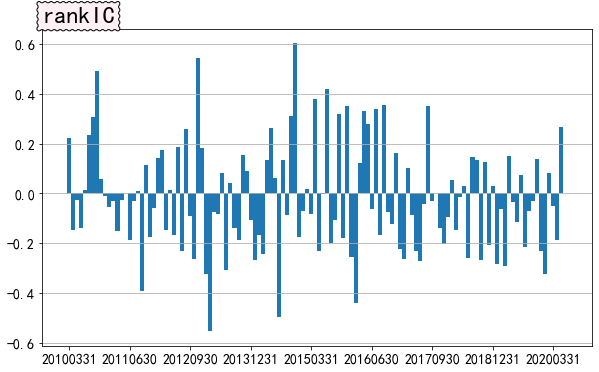

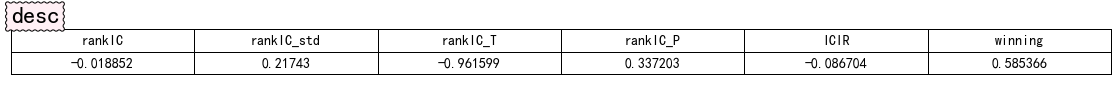

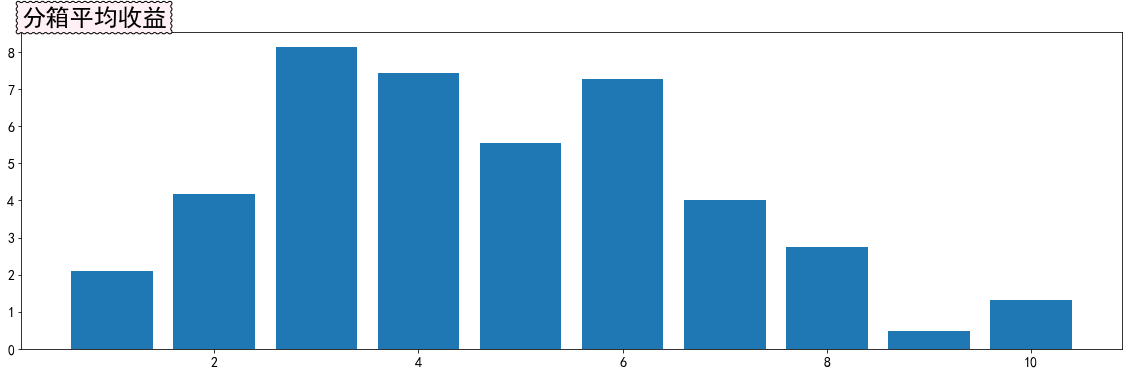

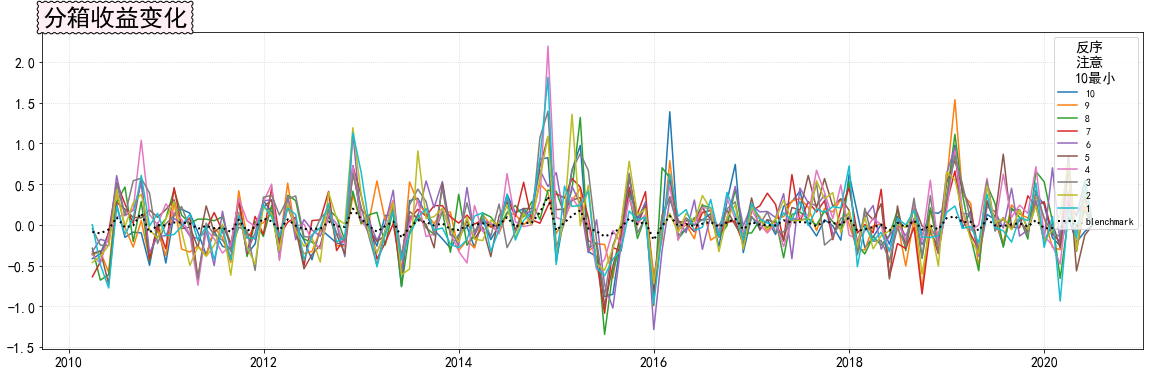

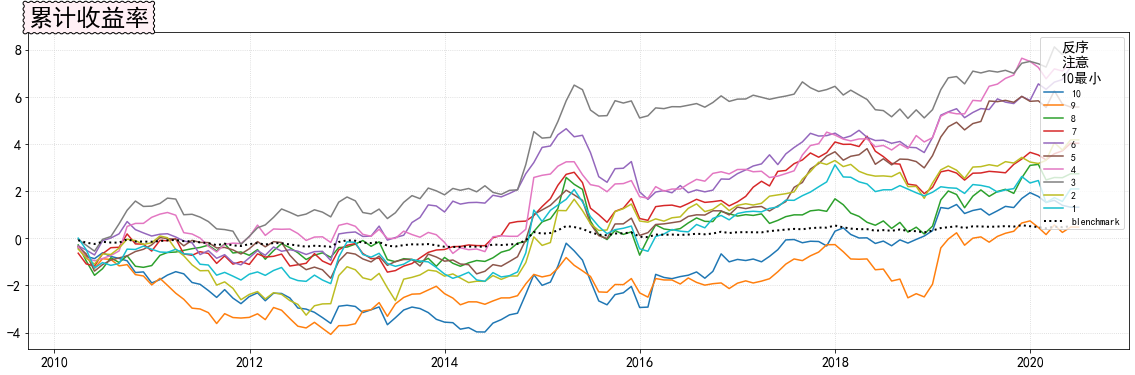

Wall time: 6.34 s


In [107]:
%%time

data = smpl.get_sample_by_zs(name='上证50', end='2020-06-29', gap=2500, only_main=True)
df = smpl.resample_stockdata_low(data.data,freq="m")
ret_forward = smpl.get_forward_return(df,'close')



obv = OBV(df)
obv.fit()
ind = obv.ind_df['main']
factor_standardized = pretreat.standardize(ind, multi_code=True)
rank_ic = af.get_rank_ic(factor_standardized, ret_forward)


fig = plt.figure(figsize=(1420/72/2,420/72))
ax = fig.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
ax.yaxis.grid()
plt.bar([pd.to_datetime(x).strftime('%Y%m%d') for x in rank_ic.index.values],rank_ic.fillna(0),width=1)
plt.title('rankIC', **PLOT_TITLE)
plt.show()


df_ = pd.DataFrame([af.get_ic_desc(rank_ic)], columns=['rankIC','rankIC_std','rankIC_T','rankIC_P'])
df_['ICIR']=round(af.get_ic_ir(rank_ic),6)
df_['winning']=round(af.get_winning_rate(rank_ic),6)

fig = plt.figure(figsize=(1420/72,420/72/7))
ax = fig.gca()
ax.xaxis.set_visible(False) 
ax.yaxis.set_visible(False)
ax.table(cellText=df_.values.round(6),colLabels=df_.columns,cellLoc='center', bbox = [0.0, 0.0, 1, 1]) 
plt.title('desc', **PLOT_TITLE)
plt.show()




ind_df = pd.concat([ind, ret_forward], axis=1)


blenchmark = smpl.get_benchmark(name='上证50', end='2020-06-29', gap=2500)
blenchmark_re = smpl.resample_stockdata_low(blenchmark.data,freq="m")
blenchmark_ret = smpl.get_forward_return(blenchmark_re,'close')
blenchmark_ret.reset_index('code',drop=True,inplace=True)
blenchmark_cum = blenchmark_ret.cumsum()
# 分箱
ind_binned = ind_df.groupby(level=0).apply(lambda x: pretreat.binning(x, deal_column='main',box_count=10, inplace=True))
# 去除绘图不需要的原始因子和code
ind_binned_noindex = ind_binned.reset_index().drop(['code', 'main'],axis=1)
# 按日期分组，组内再按分箱分组求总收益,结果会被倒序。
ind_binned_ret_date = ind_binned_noindex.set_index(['date', 'group_label']).groupby(level=0).apply(lambda x: x.groupby(level=1).apply(lambda y: y.sum()))

fig = plt.figure(figsize=(1420/72,420/72))
ind_binned_ret_all = ind_binned_noindex.drop(['date'],axis=1).set_index('group_label').groupby(level=0).apply(lambda x: x['ret_forward'].sum())
plt.bar(ind_binned_ret_all.index,ind_binned_ret_all)
plt.title('分箱平均收益', **PLOT_TITLE)
plt.show()


fig = plt.figure(figsize=(1420/72,420/72))
ind_binned_ret_date.groupby(level=1).apply(lambda x: plt.plot(x.index.get_level_values(0).unique().tolist(),x.values.tolist(),label=x.index.get_level_values(1)[0]))
plt.plot(blenchmark_ret,linestyle=":", linewidth=2,color="black",label='blenchmark')
plt.legend(loc='upper right',fontsize='x-small',title='反序\n注意\n10最小')
plt.grid(linestyle="dotted",color="lightgray")
plt.title('分箱收益变化', **PLOT_TITLE)
plt.show()


ind_binned_ret_cum = ind_binned_ret_date.groupby(level=1).apply(lambda x: x.cumsum())
fig = plt.figure(figsize=(1420/72,420/72))
ind_binned_ret_cum.groupby(level=1).apply(lambda x: plt.plot(x.index.get_level_values(0).unique().tolist(),x.values.tolist(),label=x.index.get_level_values(1)[0]))
plt.plot(blenchmark_cum,linestyle=":", linewidth=2,color="black",label='blenchmark')
plt.legend(loc='upper right',fontsize='x-small',title='反序\n注意\n10最小')
plt.grid(linestyle="dotted",color="lightgray")
plt.title('累计收益率', **PLOT_TITLE)
plt.show()


# ind_binned_ret_date




In [744]:
class FactorTest():
#     import matplotlib.pyplot as plt
#     import Analysis_Funs as af
#     import Sample_Tools as smpl
#     import Pretreat_Tools as pretreat
#     from base.Constants import PLOT_TITLE
# import matplotlib.ticker as ticker

    def __init__(self,ind_Model_Class, sample='上证50',freq="m",start=None,end=None,gap=2500,only_main=True):
        assert ((not start is None) or (not end is None)), 'start 和 end 必须有一个'
        assert isinstance(ind_Model_Class,type(Ind_Model_Base.Ind_Model)),"ind_Model_Class必须是Ind_Model的子类"
        
        self.ind_Model_Class = ind_Model_Class
        self.sample = sample
        self.freq = freq
        self.start = start
        self.end = end
        self.gap = gap
        self.only_main = only_main
        self.rank_ic = None
        self.res = None
        self.ind_ret_df = None
        self.ind_binned = None

    def process(self):
        data = smpl.get_sample_by_zs(name=self.sample, start=self.start, end=self.end, gap=self.gap, only_main=self.only_main)
        df = smpl.resample_stockdata_low(data.data,freq=self.freq)
        ret_forward = smpl.get_forward_return(df,'close')
        
        ind_obj = self.ind_Model_Class(data.data)
        ind_obj.fit()
        ind = ind_obj.ind_df['main']
        factor_standardized = pretreat.standardize(ind, multi_code=True)
        factor_standardized = smpl.resample_stockdata_low(factor_standardized,freq=self.freq)['main']

        
        self.rank_ic = af.get_rank_ic(factor_standardized, ret_forward)
        

        self.res = pd.DataFrame([af.get_ic_desc(self.rank_ic)], columns=['rankIC','rankIC_std','rankIC_T','rankIC_P'])
        self.res['ICIR']=round(af.get_ic_ir(self.rank_ic),6)
        self.res['winning']=round(af.get_winning_rate(self.rank_ic),6)
        
        ind_resample = smpl.resample_stockdata_low(ind,freq=self.freq)
        self.ind_ret_df = pd.concat([ind_resample, ret_forward], axis=1)
        # 分箱
        self.ind_binned = self.ind_ret_df.groupby(level=0).apply(lambda x: pretreat.binning(x, deal_column='main',box_count=10, inplace=True))
        
    def plot(self):
        self.rankIC_plot()
        self.binned_plot()

    def rankIC_plot(self):
        fig = plt.figure(figsize=(1420/72/2,420/72))
        ax = fig.gca()
        ax.xaxis.set_major_locator(ticker.MaxNLocator(10))
        ax.yaxis.grid()
        # 高密度时 width 必须大于1，否则会显示不出来
        width_ = 0.5
        if len(self.rank_ic) > 500:
            width_ = 1
        plt.bar([pd.to_datetime(x).strftime('%Y%m%d') for x in self.rank_ic.index.values],self.rank_ic.fillna(0),width=width_)
        plt.title('rankIC', **PLOT_TITLE)
        plt.show()

        fig = plt.figure(figsize=(1420/72,420/72/7))
        ax = fig.gca()
        ax.xaxis.set_visible(False) 
        ax.yaxis.set_visible(False)
        ax.table(cellText=df_.values.round(6),colLabels=df_.columns,cellLoc='center', bbox = [0.0, 0.0, 1, 1]) 
        plt.title('desc', **PLOT_TITLE)
        plt.show()


    def binned_plot(self):
        # 去除绘图不需要的原始因子和code
        ind_binned_noindex = self.ind_binned.reset_index().drop(['code', 'main'],axis=1)
        # 按日期分组，组内再按分箱分组求总收益,结果会被倒序。
        ind_binned_ret_date = ind_binned_noindex.set_index(['date', 'group_label']).groupby(level=0).apply(lambda x: x.groupby(level=1).apply(lambda y: y.sum()))

        fig = plt.figure(figsize=(1420/72,420/72))
        ind_binned_ret_all = ind_binned_noindex.drop(['date'],axis=1).set_index('group_label').groupby(level=0).apply(lambda x: x['ret_forward'].sum())
        plt.bar(ind_binned_ret_all.index,ind_binned_ret_all)
        plt.title('分箱平均收益', **PLOT_TITLE)
        plt.show()

        blenchmark = smpl.get_benchmark(name=self.sample, start=self.start, end=self.end, gap=self.gap)
        blenchmark_re = smpl.resample_stockdata_low(blenchmark.data,freq=self.freq)
        blenchmark_ret = smpl.get_forward_return(blenchmark_re,'close')
        blenchmark_ret.reset_index('code',drop=True,inplace=True)
        blenchmark_cum = blenchmark_ret.cumsum()

        fig = plt.figure(figsize=(1420/72,420/72))
        ind_binned_ret_date.groupby(level=1).apply(lambda x: plt.plot(x.index.get_level_values(0).unique().tolist(),x.values.tolist(),label=x.index.get_level_values(1)[0]))
        plt.plot(blenchmark_ret,linestyle=":", linewidth=2,color="black",label='blenchmark')
        plt.legend(loc='upper right',fontsize='x-small',title='反序\n注意\n10最小')
        plt.grid(linestyle="dotted",color="lightgray")
        plt.title('分箱收益变化', **PLOT_TITLE)
        plt.show()

        ind_binned_ret_cum = ind_binned_ret_date.groupby(level=1).apply(lambda x: x.cumsum())
        fig = plt.figure(figsize=(1420/72,420/72))
        ind_binned_ret_cum.groupby(level=1).apply(lambda x: plt.plot(x.index.get_level_values(0).unique().tolist(),x.values.tolist(),label=x.index.get_level_values(1)[0]))
        plt.plot(blenchmark_cum,linestyle=":", linewidth=2,color="black",label='blenchmark')
        plt.legend(loc='upper right',fontsize='x-small',title='反序\n注意\n10最小')
        plt.grid(linestyle="dotted",color="lightgray")
        plt.title('累计收益率', **PLOT_TITLE)
        plt.show()


In [87]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(ic_datax)
# 000016 上证50
# 000300 沪深300 
# def QA_fetch_index_day_adv(code,start,end=None)


# blenchmark = smpl.get_benchmark(name='上证50', end='2020-06-29', gap=250)
# blenchmark_re = smpl.resample_stockdata_low(blenchmark.data,freq="m")
# blenchmark_ret = smpl.get_forward_return(blenchmark_re,'close')
# blenchmark_ret.reset_index('code',drop=True,inplace=True)
# blenchmark_cum = blenchmark_ret.cumsum()

# print(blenchmark_re)
# print(blenchmark_ret)
# print(blenchmark_cum)
# fig = plt.figure(figsize=(1420/72,420/72))
# plt.plot(blenchmark_ret,color="red")
# plt.plot(blenchmark_cum,linestyle=":", linewidth=2,color="black")
# plt.show()
# print(smpl.resample_stockdata_low(ind,freq='m') )
# print(df)

date
2010-03-16       0.124467
2010-03-17      -0.301802
2010-03-18     -0.0804894
2010-03-19      0.0938834
2010-03-22      -0.152205
2010-03-23      0.0564248
2010-03-24      0.0784732
2010-03-25      -0.165007
2010-03-26      0.0252252
2010-03-29     -0.0761905
2010-03-30      -0.215444
2010-03-31       0.489575
2010-04-01      -0.239109
2010-04-02     -0.0229967
2010-04-06       0.218113
2010-04-07       0.238353
2010-04-08       0.329987
2010-04-09      0.0596639
2010-04-12      -0.428314
2010-04-13      -0.513039
2010-04-14      -0.213845
2010-04-15      -0.616169
2010-04-16       0.366947
2010-04-19       0.276705
2010-04-20       0.320448
2010-04-21      -0.264607
2010-04-22      -0.316409
2010-04-23       0.100901
2010-04-26       0.315686
2010-04-27      -0.295238
2010-04-28       0.068602
2010-04-29      -0.364736
2010-04-30      -0.111197
2010-05-04       0.229344
2010-05-05       -0.47155
2010-05-06       0.111078
2010-05-07      -0.456113
2010-05-10       0.124324
2010-05

In [593]:
%%time
# blenchmark.close_pct_change?
# mean,std,t_static,p_value = af.get_ic_desc(rank_ic)

# test = FactorTest(OBV, sample='沪深300',freq="m",end='2020-06-29',gap=2500,only_main=True)
# test.process()
# test.plot()

# smpl.financial_dict('totalCapital')

# factor_standardized
# index_=factor_standardized.index.get_level_values(0)
# start_ = index_.min()
# end_ = index_.max()
# print(start_, end_)

# start_year, end_year, quarter_ordesr=[1,2,3,4],
# smpl.get_quarter_list()

# QA_fetch_financial_report(code, report_date, ltype='EN', db=DATABASE)


# QA_fetch_financial_report_adv(code, start, end=None, ltype='EN')


#  "2011Q3", 
# QA.QA_fetch_financial_report_adv('000001', "2012Q1","2022Q1",ltype='EN').data[['totalCapital','totalCapital']]
# a = smpl.get_quarter_list(2019, 2021, quarter_ordesr=[1,2,3,4], generate_label=False)
# print(QA.QA_fetch_financial_report('000001',a ,ltype='EN')[['totalCapital','totalCapital']])

# dd = smpl.get_sample_by_zs(name='上证50', end='2011-04-15', gap=265, only_main=True)
# ddr = smpl.resample_stockdata_low(dd.data,freq="w")

# df_sorted = ddr.sort_index(level=0)
# data_df = df_sorted.loc[pd.Timestamp('2010-02-24'):pd.Timestamp('2011-04-15'),['600000','600009','600016'],:]
# report_df = QA.QA_fetch_financial_report_adv(['600000','600009','600016'], "2010Q1","2011Q1",ltype='EN').data[['totalCapital','fixedAssets']]

# data_df.groupby(level=1).apply(lambda x: print(x))
# ss_6 = ss.loc[(slice(None), '600000'), :]
# ff_6 = ff.loc[(slice(None), '600000'), :]




# report_starts = report_df.index.get_level_values(0)
# report_ends = list(map(lambda x: pd.Timestamp(smpl.get_next_report_date(x))- pd.Timedelta(days=1), [str(i)[0:10] for i in report_starts]))
# report_df = report_df.assign(start=report_starts,end=report_ends) 


# ind_names = report_df.columns.tolist()
# ind_names.remove('start')
# ind_names.remove('end')

# inds = []
# for ind_name in ind_names:
#     series_tmp = []
#     for report in report_df.itertuples():
# #         print(report.Index[1] )
#         code = report.Index[1]
#         index_slice=data_df.loc[(slice(getattr(report,'start'),getattr(report,'end')), code), :].index
#         series_tmp.append(pd.Series(getattr(report,ind_name),index=index_slice,name=ind_name))
#     inds.append(pd.concat(series_tmp,axis=0))
    
        
# index_=data_df.loc[(slice('2010-03-31','2010-06-30'), '600000'), :].index
# xxx=pd.Series(8.830045e+09,index=index_,name='totalCapital')
# # data_df[xxx.name] = xxx
# data_df =pd.concat([ss,xxx],axis=1)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(pd.concat([data_df,*inds],axis=1))
# print(report_df)  
# print(data_df)  

Wall time: 74 ms


In [2]:
%%time


ttt2 = smpl.get_sample_by_zs(name='上证50', end='2010-04-15', gap=265, only_main=True)
ttt3 = smpl.resample_stockdata_low(ttt2.data,freq="w")


ttt3 = smpl.add_report_inds(ttt3)
ttt3 = smpl.add_industry(ttt3)

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(ttt3)
ttt4 = ttt3.dropna(axis=0)
ttt4 = ttt4.drop(ttt4[ttt4['totalCapital']==0].index)
close = ttt4.close
ttt4 = ttt4[['totalCapital','industry']]

# print(ttt4[pd.isna(ttt4)])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     print(ttt4[ttt4['totalCapital']==0])
pp = pretreat.neutralize(close, ttt4, categorical=['industry'], logarithmetics=['totalCapital'])
print(pp)



# print(pd.get_dummies(ttt4,['industry']))

date        code  
2009-03-22  600000    -6.121928
            600009    -2.119464
            600016   -13.002685
            600028    -2.797857
            600030     0.425699
                        ...    
2010-04-18  601668     0.198150
            601688    -2.211282
            601857    -0.111429
            601888    -0.332000
            601899   -18.626462
Name: close, Length: 1955, dtype: float64
Wall time: 4.65 s


In [742]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(pd.concat([pp,ttt4,close],axis=1))

                        close  totalCapital   close
date       code                                    
2009-03-22 600000   -5.471715  5.661347e+09   19.31
           600009  -15.541563  1.926958e+09   13.78
           600016  -14.880791  1.882300e+10    4.84
           600028   -4.516670  8.670244e+10    8.77
           600030   -0.976090  6.630468e+09   23.14
           600031   -7.030526  1.488000e+09   23.38
           600036   -5.930188  1.470718e+10   14.83
           600048   -6.715934  2.452343e+09   21.59
           600050  -13.850515  2.119660e+10    5.37
           600104  -14.626863  6.551029e+09    9.54
           600196  -18.146114  1.237775e+09   13.04
           600276    4.628622  5.172860e+08   39.49
           600309  -16.051294  1.663334e+09   13.89
           600438  -25.052954  6.875200e+08    8.61
           600519   85.551651  9.438000e+08  117.88
           600547   37.991827  3.557681e+08   74.43
           600570  -22.258379  2.970240e+08   14.94
           6

In [711]:
# from QUANTAXIS.QAData.financial_mean import financial_dict
# financial_dict
close

date        code  
2009-03-22  600000    19.31
            600009    13.78
            600016     4.84
            600028     8.77
            600030    23.14
                      ...  
2010-04-18  601668     4.24
            601688    21.57
            601857    13.23
            601888    18.68
            601899     8.81
Name: close, Length: 1970, dtype: float64